In [12]:
import torch
from collections import Counter
from torchvision import datasets
import matplotlib.pyplot as plt
import cv2
import numpy as np
import plotly.graph_objects as go
import torchvision.transforms.functional as F

In [2]:
dataset = datasets.SBDataset(
    root='../data',
    mode='segmentation',
    download=False,
)

## Visualization

(500, 333)
(500, 375)
(333, 500)


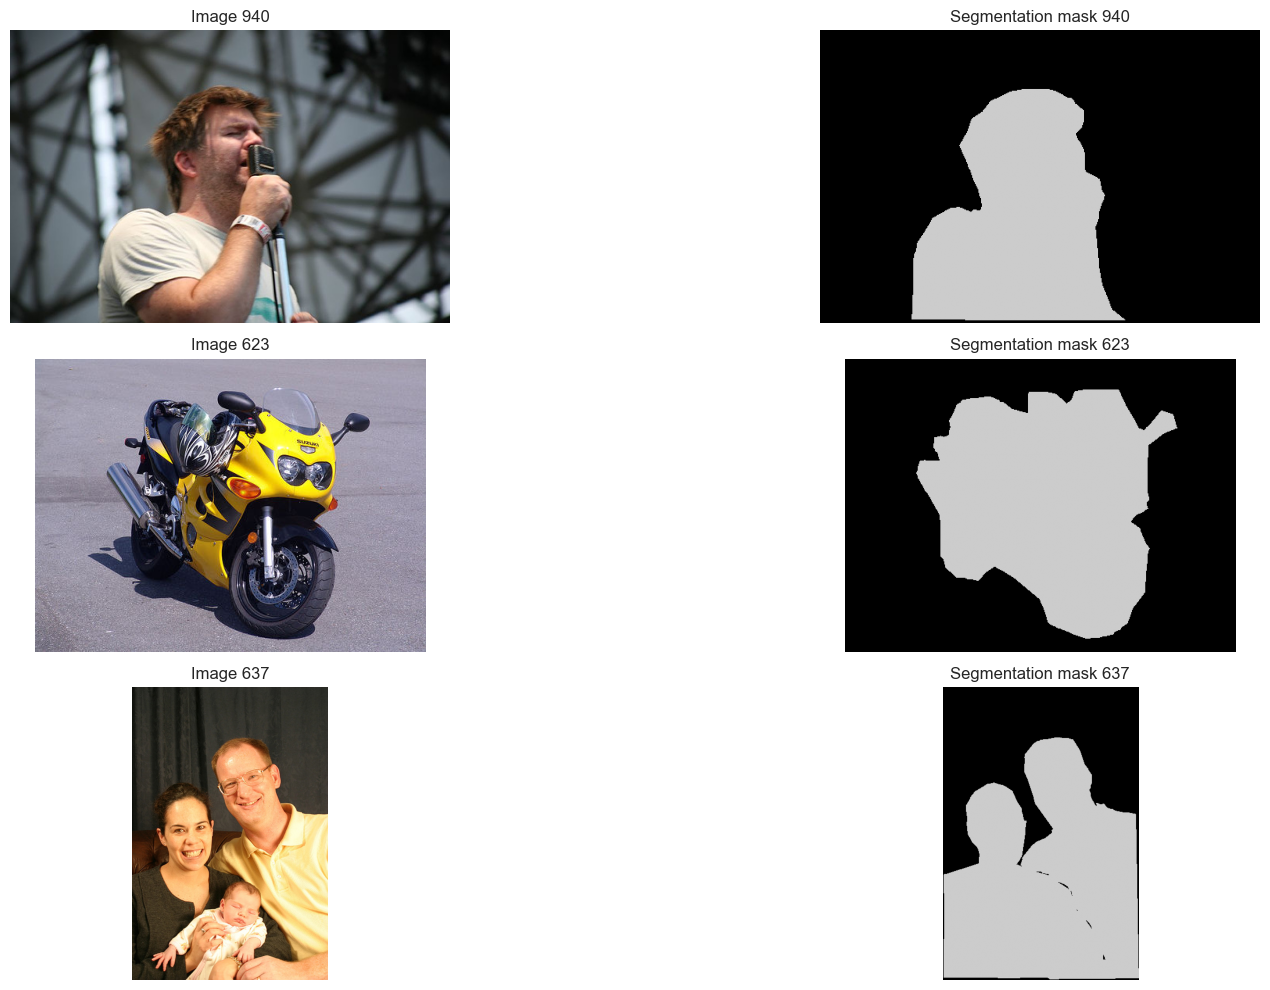

In [18]:
indexes = np.random.randint(0, 1000, 3)

plt.style.use('seaborn-v0_8')
plt.figure(figsize=(20, 10))

for (i, idx) in enumerate(indexes):
    
    img, target = dataset[idx]
    print(img.size)
    
    plt.subplot(3, 2, 2*i + 1)
    plt.imshow(img)
    plt.title(f"Image {idx}")
    plt.axis('off')

    plt.subplot(3, 2, 2*i + 2)
    plt.imshow(target, cmap='nipy_spectral')
    plt.title(f"Segmentation mask {idx}")
    plt.axis('off')

plt.tight_layout()
plt.show()

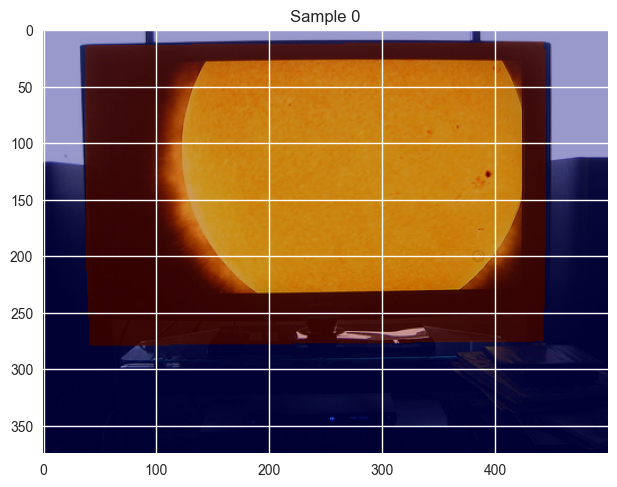

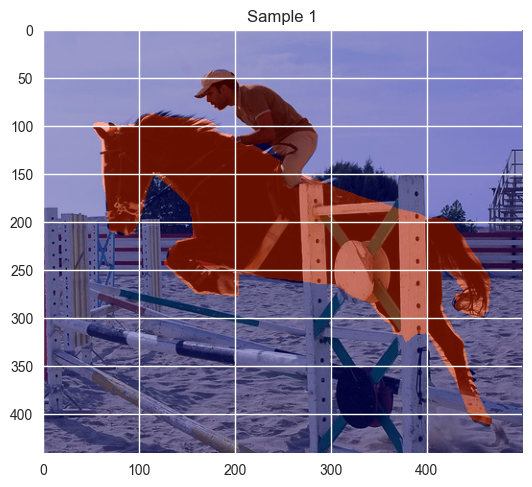

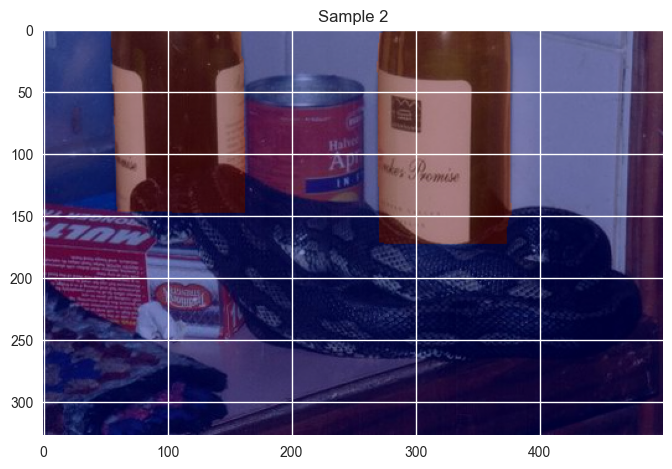

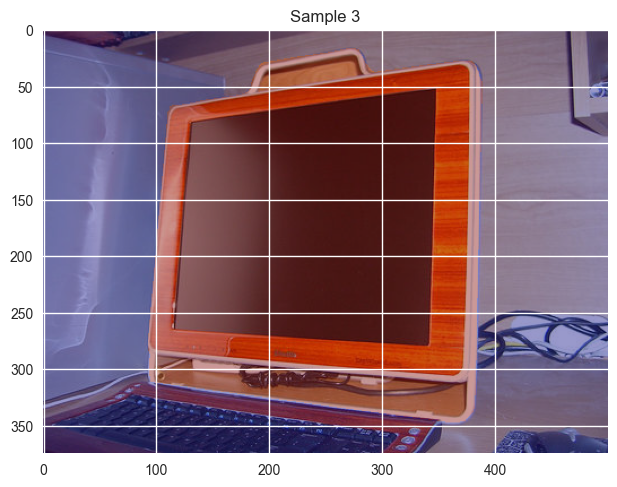

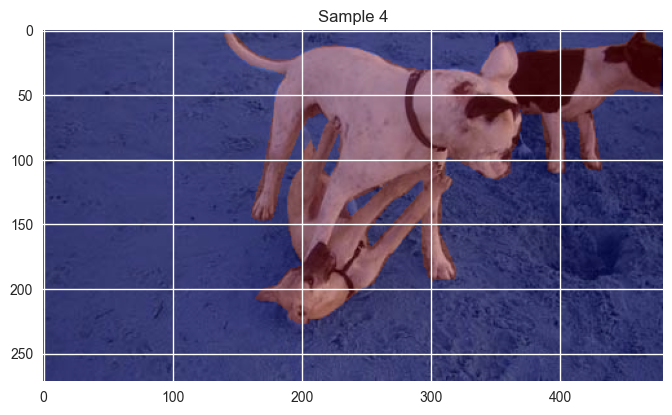

In [13]:
for i in range(5):
    img, mask = dataset[i]
    plt.imshow(F.to_tensor(img).permute(1, 2, 0))
    plt.imshow(np.array(mask), alpha=0.4, cmap='jet')
    plt.title(f"Sample {i}")
    plt.show()

## Unique classes

In [9]:
print(f"Total samples: {len(dataset)}")

Total samples: 8498


In [5]:
label_counter = Counter()

for i in range(len(dataset)):
    _, target = dataset[i]
    mask = np.array(target)
    label_counter.update(np.unique(mask).tolist())

label_counter.pop(0)

print(label_counter)

Counter({15: 3014, 12: 923, 7: 871, 9: 822, 8: 797, 3: 595, 5: 542, 1: 458, 20: 430, 2: 402, 19: 397, 11: 396, 16: 393, 14: 384, 18: 373, 4: 367, 13: 352, 6: 330, 17: 251, 10: 222})


In [6]:
VOC_CLASSES = {
     1: "aeroplane",
     2: "bicycle",
     3: "bird",
     4: "boat",
     5: "bottle",
     6: "bus",
     7: "car",
     8: "cat",
     9: "chair",
    10: "cow",
    11: "diningtable",
    12: "dog",
    13: "horse",
    14: "motorbike",
    15: "person",
    16: "pottedplant",
    17: "sheep",
    18: "sofa",
    19: "train",
    20: "tvmonitor"
}

In [8]:
labels = [VOC_CLASSES[k] for k in label_counter]
counts = [label_counter[k] for k in label_counter]

fig = go.Figure([go.Bar(x=labels, y=counts)])
fig.update_layout(
    title="Class Distribution",
    xaxis_title="Class",
    yaxis_title="Number of Occurrences",
    xaxis_tickangle=-45,
    template="plotly_white"
)

fig.show()